In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

ROOT = Path.home() / "Desktop" / "FinCascade"

DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
GRAPH_DIR = ROOT / "graph"

MODEL_DIR.mkdir(exist_ok=True)

print("ML environment ready.")

ML environment ready.


In [2]:
returns = pd.read_csv(
    DATA_DIR / "market_returns_model.csv",
    index_col=0,
    parse_dates=True
)

metadata = pd.read_csv(
    DATA_DIR / "entities.csv"
)

print("Returns shape:", returns.shape)
print("Entities:", len(metadata))

print(
    "Date range:",
    returns.index.min(),
    "to",
    returns.index.max()
)

print("\nMissing values:")
print(returns.isna().sum().sum())

Returns shape: (1396, 26)
Entities: 26
Date range: 2021-01-05 00:00:00 to 2026-09-01 00:00:00

Missing values:
0


In [3]:
TARGET = "ONGC.NS"

# Today's market information, excluding ONGC itself
X = returns.drop(columns=[TARGET]).copy()

# ONGC return on the next trading day
y = returns[TARGET].shift(-1)

# Remove last row because next-day target is unavailable
X = X.iloc[:-1].copy()
y = y.iloc[:-1].copy()

print("Target:", TARGET)
print("Number of features:", X.shape[1])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

Target: ONGC.NS
Number of features: 25
X shape: (1395, 25)
y shape: (1395,)

Missing values in X: 0
Missing values in y: 0


In [4]:
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain dates:")
print(X_train.index.min(), "→", X_train.index.max())

print("\nValidation dates:")
print(X_val.index.min(), "→", X_val.index.max())

print("\nTest dates:")
print(X_test.index.min(), "→", X_test.index.max())

Train: (976, 25)
Validation: (209, 25)
Test: (210, 25)

Train dates:
2021-01-05 00:00:00 → 2024-12-17 00:00:00

Validation dates:
2024-12-18 00:00:00 → 2025-10-21 00:00:00

Test dates:
2025-10-23 00:00:00 → 2026-08-31 00:00:00


In [5]:
baseline_pred = np.zeros(len(y_val))

baseline_mae = mean_absolute_error(
    y_val,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_val,
    baseline_pred
)

print("ZERO-RETURN BASELINE")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

ZERO-RETURN BASELINE
MAE : 0.011662922199554756
RMSE: 0.015543004948750763
R²  : -0.0006170545416128714


In [6]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(X_val)

linear_mae = mean_absolute_error(
    y_val,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_val,
    linear_pred
)

print("LINEAR REGRESSION")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

LINEAR REGRESSION
MAE : 0.010950045124444429
RMSE: 0.014924589301331318
R²  : 0.07742282011858392


In [7]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred = ridge_model.predict(X_val)

ridge_mae = mean_absolute_error(
    y_val,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_val,
    ridge_pred
)

print("RIDGE REGRESSION")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

RIDGE REGRESSION
MAE : 0.010927298993086922
RMSE: 0.01490277444919043
R²  : 0.08011785924387604


In [8]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_val)

rf_mae = mean_absolute_error(
    y_val,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_val,
    rf_pred
)

print("RANDOM FOREST")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

RANDOM FOREST
MAE : 0.010600130943020376
RMSE: 0.01460988941278785
R²  : 0.1159195490628312


In [9]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_val)

xgb_mae = mean_absolute_error(
    y_val,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_val,
    xgb_pred
)

print("XGBOOST")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBOOST
MAE : 0.01079417905856659
RMSE: 0.014891692873081232
R²  : 0.08148538366001012


In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Zero Return Baseline",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        baseline_mae,
        linear_mae,
        ridge_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        baseline_rmse,
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2": [
        baseline_r2,
        linear_r2,
        ridge_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison = comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

comparison

,Model,MAE,RMSE,R2
0,Random Forest,0.010600,0.014610,0.115920
1,XGBoost,0.010794,0.014892,0.081485
2,Ridge Regression,0.010927,0.014903,0.080118
3,Linear Regression,0.010950,0.014925,0.077423
4,Zero Return Baseline,0.011663,0.015543,-0.000617


In [11]:
rf_importance = pd.DataFrame({
    "ticker": X_train.columns,
    "importance": rf_model.feature_importances_
})

ticker_name_map = metadata.set_index(
    "ticker"
)["name"].to_dict()

rf_importance["name"] = (
    rf_importance["ticker"].map(ticker_name_map)
)

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

rf_importance.head(15)

,ticker,importance,name
0,CL=F,0.242233,Crude Oil
1,RELIANCE.NS,0.078135,Reliance
2,MARUTI.NS,0.058505,Maruti Suzuki
3,ICICIBANK.NS,0.048689,ICICI Bank
4,AXISBANK.NS,0.047761,Axis Bank
5,HINDUNILVR.NS,0.046075,Hindustan Unilever
6,GODREJPROP.NS,0.039402,Godrej Properties
7,HDFCBANK.NS,0.036025,HDFC Bank
8,DRREDDY.NS,0.030757,Dr Reddy's
9,DLF.NS,0.030079,DLF


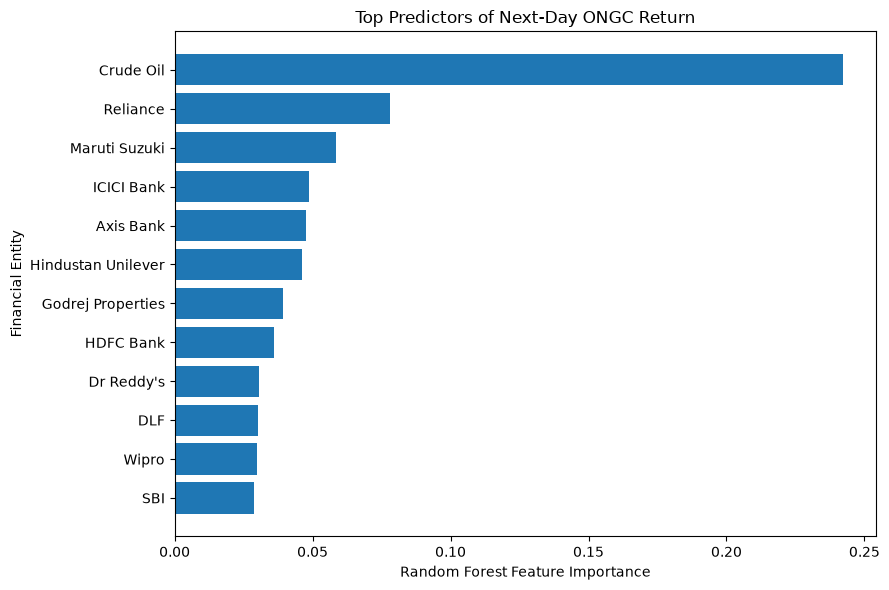

In [12]:
top_features = rf_importance.head(12).sort_values(
    "importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["name"],
    top_features["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Financial Entity")

plt.title(
    "Top Predictors of Next-Day ONGC Return"
)

plt.tight_layout()
plt.show()

In [13]:
rf_importance["ml_weight"] = (
    rf_importance["importance"]
    /
    rf_importance["importance"].sum()
)

print(
    "Total ML weight:",
    rf_importance["ml_weight"].sum()
)

rf_importance[
    [
        "ticker",
        "name",
        "ml_weight"
    ]
].head(15)

Total ML weight: 0.9999999999999999


,ticker,name,ml_weight
0,CL=F,Crude Oil,0.242233
1,RELIANCE.NS,Reliance,0.078135
2,MARUTI.NS,Maruti Suzuki,0.058505
3,ICICIBANK.NS,ICICI Bank,0.048689
4,AXISBANK.NS,Axis Bank,0.047761
5,HINDUNILVR.NS,Hindustan Unilever,0.046075
6,GODREJPROP.NS,Godrej Properties,0.039402
7,HDFCBANK.NS,HDFC Bank,0.036025
8,DRREDDY.NS,Dr Reddy's,0.030757
9,DLF.NS,DLF,0.030079


In [14]:
crude_ml = rf_importance[
    rf_importance["ticker"] == "CL=F"
]

crude_rank = (
    rf_importance.index[
        rf_importance["ticker"] == "CL=F"
    ][0] + 1
)

crude_lag = 0.247247

print("===== CRUDE OIL → ONGC =====")

print("\nRandom Forest importance:")
print(crude_ml["importance"].iloc[0])

print("\nML importance rank:")
print(
    f"{crude_rank} out of {len(rf_importance)} predictors"
)

print("\nLagged correlation:")
print(crude_lag)

===== CRUDE OIL → ONGC =====

Random Forest importance:
0.24223324083284944

ML importance rank:
1 out of 25 predictors

Lagged correlation:
0.247247


In [15]:
def train_dependency_model(target, returns):

    X = returns.drop(columns=[target]).copy()
    y = returns[target].shift(-1)

    X = X.iloc[:-1]
    y = y.iloc[:-1]

    n = len(X)
    train_end = int(n * 0.70)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    importance = pd.DataFrame({
        "source": X.columns,
        "target": target,
        "ml_importance": model.feature_importances_
    })

    return importance

In [16]:
all_ml_dependencies = []

targets = list(returns.columns)

for i, target in enumerate(targets, start=1):

    print(
        f"Training {i}/{len(targets)}:",
        target
    )

    importance = train_dependency_model(
        target,
        returns
    )

    all_ml_dependencies.append(
        importance
    )

ml_dependencies = pd.concat(
    all_ml_dependencies,
    ignore_index=True
)

print("\nFinished.")
print("Total ML relationships:", len(ml_dependencies))

Training 1/26: AXISBANK.NS
Training 2/26: BAJAJFINSV.NS
Training 3/26: BAJFINANCE.NS
Training 4/26: CL=F
Training 5/26: DLF.NS
Training 6/26: DRREDDY.NS
Training 7/26: GC=F
Training 8/26: GODREJPROP.NS
Training 9/26: HCLTECH.NS
Training 10/26: HDFCBANK.NS
Training 11/26: HINDUNILVR.NS
Training 12/26: ICICIBANK.NS
Training 13/26: INFY.NS
Training 14/26: INR=X
Training 15/26: ITC.NS
Training 16/26: M&M.NS
Training 17/26: MARUTI.NS
Training 18/26: ONGC.NS
Training 19/26: RELIANCE.NS
Training 20/26: SBIN.NS
Training 21/26: SUNPHARMA.NS
Training 22/26: TCS.NS
Training 23/26: TMPV.NS
Training 24/26: WIPRO.NS
Training 25/26: ^NSEBANK
Training 26/26: ^NSEI

Finished.
Total ML relationships: 650


In [17]:
ticker_name_map = metadata.set_index(
    "ticker"
)["name"].to_dict()

ml_dependencies["source_name"] = (
    ml_dependencies["source"].map(
        ticker_name_map
    )
)

ml_dependencies["target_name"] = (
    ml_dependencies["target"].map(
        ticker_name_map
    )
)

ml_dependencies = ml_dependencies.sort_values(
    "ml_importance",
    ascending=False
).reset_index(drop=True)

ml_dependencies[
    [
        "source",
        "source_name",
        "target",
        "target_name",
        "ml_importance"
    ]
].head(25)

,source,source_name,target,target_name,ml_importance
0,CL=F,Crude Oil,ONGC.NS,ONGC,0.245265
1,CL=F,Crude Oil,HINDUNILVR.NS,Hindustan Unilever,0.226881
2,GC=F,Gold,INR=X,USD/INR,0.175178
3,ITC.NS,ITC,ICICIBANK.NS,ICICI Bank,0.131243
4,SUNPHARMA.NS,Sun Pharma,HCLTECH.NS,HCL Tech,0.127687
5,ITC.NS,ITC,SBIN.NS,SBI,0.124382
6,HCLTECH.NS,HCL Tech,TMPV.NS,Tata Motors Passenger Vehicles,0.117834
7,ICICIBANK.NS,ICICI Bank,^NSEI,NIFTY 50,0.104552
8,BAJFINANCE.NS,Bajaj Finance,TCS.NS,TCS,0.099704
9,SBIN.NS,SBI,ITC.NS,ITC,0.096806


In [18]:
def evaluate_target_model(target, returns):

    X = returns.drop(columns=[target]).copy()
    y = returns[target].shift(-1)

    X = X.iloc[:-1]
    y = y.iloc[:-1]

    n = len(X)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    X_train = X.iloc[:train_end]
    X_val = X.iloc[train_end:val_end]

    y_train = y.iloc[:train_end]
    y_val = y.iloc[train_end:val_end]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    rf_mae = mean_absolute_error(y_val, pred)

    rf_rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    rf_r2 = r2_score(y_val, pred)

    # Zero-return baseline
    baseline_pred = np.zeros(len(y_val))

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_val,
            baseline_pred
        )
    )

    improvement = (
        (baseline_rmse - rf_rmse)
        / baseline_rmse
    ) * 100

    return {
        "target": target,
        "rf_mae": rf_mae,
        "rf_rmse": rf_rmse,
        "rf_r2": rf_r2,
        "baseline_rmse": baseline_rmse,
        "improvement_pct": improvement
    }

In [19]:
model_results = []

for i, target in enumerate(returns.columns, start=1):

    print(
        f"Evaluating {i}/{len(returns.columns)}:",
        target
    )

    result = evaluate_target_model(
        target,
        returns
    )

    model_results.append(result)

model_performance = pd.DataFrame(
    model_results
)

print("\nEvaluation complete.")
print("Models evaluated:", len(model_performance))

Evaluating 1/26: AXISBANK.NS
Evaluating 2/26: BAJAJFINSV.NS
Evaluating 3/26: BAJFINANCE.NS
Evaluating 4/26: CL=F
Evaluating 5/26: DLF.NS
Evaluating 6/26: DRREDDY.NS
Evaluating 7/26: GC=F
Evaluating 8/26: GODREJPROP.NS
Evaluating 9/26: HCLTECH.NS
Evaluating 10/26: HDFCBANK.NS
Evaluating 11/26: HINDUNILVR.NS
Evaluating 12/26: ICICIBANK.NS
Evaluating 13/26: INFY.NS
Evaluating 14/26: INR=X
Evaluating 15/26: ITC.NS
Evaluating 16/26: M&M.NS
Evaluating 17/26: MARUTI.NS
Evaluating 18/26: ONGC.NS
Evaluating 19/26: RELIANCE.NS
Evaluating 20/26: SBIN.NS
Evaluating 21/26: SUNPHARMA.NS
Evaluating 22/26: TCS.NS
Evaluating 23/26: TMPV.NS
Evaluating 24/26: WIPRO.NS
Evaluating 25/26: ^NSEBANK
Evaluating 26/26: ^NSEI

Evaluation complete.
Models evaluated: 26


In [20]:
ticker_name_map = metadata.set_index(
    "ticker"
)["name"].to_dict()

model_performance["name"] = (
    model_performance["target"].map(
        ticker_name_map
    )
)

model_performance["beats_baseline"] = (
    model_performance["rf_rmse"]
    <
    model_performance["baseline_rmse"]
)

performance_display = model_performance[
    [
        "target",
        "name",
        "rf_mae",
        "rf_rmse",
        "baseline_rmse",
        "rf_r2",
        "improvement_pct",
        "beats_baseline"
    ]
].sort_values(
    "improvement_pct",
    ascending=False
)

print(
    "Models beating baseline:",
    model_performance["beats_baseline"].sum(),
    "/",
    len(model_performance)
)

performance_display

Models beating baseline: 8 / 26


,target,name,rf_mae,rf_rmse,baseline_rmse,rf_r2,improvement_pct,beats_baseline
17,ONGC.NS,ONGC,0.010583,0.014570,0.015543,0.120795,6.262967,True
13,INR=X,USD/INR,0.002145,0.002965,0.003087,0.075069,3.966319,True
8,HCLTECH.NS,HCL Tech,0.011608,0.016617,0.016725,0.010070,0.645203,True
2,BAJFINANCE.NS,Bajaj Finance,0.012248,0.016768,0.016857,-0.008891,0.527839,True
12,INFY.NS,Infosys,0.011628,0.016245,0.016331,0.006569,0.525812,True
15,M&M.NS,Mahindra & Mahindra,0.013817,0.018044,0.018102,0.003256,0.322970,True
5,DRREDDY.NS,Dr Reddy's,0.010216,0.013552,0.013571,0.002484,0.139062,True
18,RELIANCE.NS,Reliance,0.009629,0.012981,0.012995,-0.001615,0.105492,True
3,CL=F,Crude Oil,0.015073,0.020522,0.020468,-0.005610,-0.264428,False
19,SBIN.NS,SBI,0.008916,0.011969,0.011932,-0.008759,-0.309777,False


In [21]:
reliable_targets = model_performance[
    (model_performance["beats_baseline"] == True)
    &
    (model_performance["rf_r2"] > 0)
].copy()

reliable_targets = reliable_targets.sort_values(
    "improvement_pct",
    ascending=False
)

print(
    "Validation-reliable targets:",
    len(reliable_targets),
    "/",
    len(model_performance)
)

Validation-reliable targets: 6 / 26


In [22]:
reliable_targets[
    [
        "target",
        "name",
        "rf_rmse",
        "baseline_rmse",
        "rf_r2",
        "improvement_pct"
    ]
]

,target,name,rf_rmse,baseline_rmse,rf_r2,improvement_pct
17,ONGC.NS,ONGC,0.014570,0.015543,0.120795,6.262967
13,INR=X,USD/INR,0.002965,0.003087,0.075069,3.966319
8,HCLTECH.NS,HCL Tech,0.016617,0.016725,0.010070,0.645203
12,INFY.NS,Infosys,0.016245,0.016331,0.006569,0.525812
15,M&M.NS,Mahindra & Mahindra,0.018044,0.018102,0.003256,0.322970
5,DRREDDY.NS,Dr Reddy's,0.013552,0.013571,0.002484,0.139062


In [23]:
def evaluate_on_test(target, returns):

    X = returns.drop(columns=[target]).copy()
    y = returns[target].shift(-1)

    X = X.iloc[:-1]
    y = y.iloc[:-1]

    n = len(X)

    train_val_end = int(n * 0.85)

    X_train_val = X.iloc[:train_val_end]
    X_test = X.iloc[train_val_end:]

    y_train_val = y.iloc[:train_val_end]
    y_test = y.iloc[train_val_end:]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_val,
        y_train_val
    )

    test_pred = model.predict(X_test)

    rf_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    rf_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    rf_r2 = r2_score(
        y_test,
        test_pred
    )

    # Zero-return baseline
    zero_pred = np.zeros(len(y_test))

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            zero_pred
        )
    )

    improvement = (
        (baseline_rmse - rf_rmse)
        / baseline_rmse
    ) * 100

    return {
        "target": target,
        "test_mae": rf_mae,
        "test_rmse": rf_rmse,
        "test_baseline_rmse": baseline_rmse,
        "test_r2": rf_r2,
        "test_improvement_pct": improvement,
        "test_beats_baseline": rf_rmse < baseline_rmse
    }

In [24]:
test_results = []

for target in reliable_targets["target"]:

    print("Testing:", target)

    result = evaluate_on_test(
        target,
        returns
    )

    test_results.append(result)

test_performance = pd.DataFrame(
    test_results
)

test_performance["name"] = (
    test_performance["target"].map(
        ticker_name_map
    )
)

test_performance = test_performance[
    [
        "target",
        "name",
        "test_mae",
        "test_rmse",
        "test_baseline_rmse",
        "test_r2",
        "test_improvement_pct",
        "test_beats_baseline"
    ]
].sort_values(
    "test_improvement_pct",
    ascending=False
)

print(
    "\nModels beating baseline on TEST:",
    test_performance[
        "test_beats_baseline"
    ].sum(),
    "/",
    len(test_performance)
)

test_performance

Testing: ONGC.NS
Testing: INR=X
Testing: HCLTECH.NS
Testing: INFY.NS
Testing: M&M.NS
Testing: DRREDDY.NS

Models beating baseline on TEST: 1 / 6


,target,name,test_mae,test_rmse,test_baseline_rmse,test_r2,test_improvement_pct,test_beats_baseline
4,M&M.NS,Mahindra & Mahindra,0.013614,0.017441,0.017453,0.001122,0.071165,True
1,INR=X,USD/INR,0.003241,0.004911,0.004906,-0.008073,-0.089062,False
2,HCLTECH.NS,HCL Tech,0.012976,0.018772,0.018735,-0.004059,-0.195770,False
5,DRREDDY.NS,Dr Reddy's,0.010552,0.015528,0.015330,-0.026236,-1.286998,False
3,INFY.NS,Infosys,0.013978,0.019536,0.019284,-0.028940,-1.308552,False
0,ONGC.NS,ONGC,0.011905,0.016614,0.015720,-0.116977,-5.686794,False


In [25]:
model_performance.to_csv(
    DATA_DIR / "ml_validation_performance.csv",
    index=False
)

test_performance.to_csv(
    DATA_DIR / "ml_test_performance.csv",
    index=False
)

ml_dependencies.to_csv(
    DATA_DIR / "ml_dependencies_experimental.csv",
    index=False
)

print("ML experiment results saved.")

print("\nValidation models beating baseline:")
print(model_performance["beats_baseline"].sum(), "/ 26")

print("\nTest models beating baseline:")
print(test_performance["test_beats_baseline"].sum(), "/", len(test_performance))

ML experiment results saved.

Validation models beating baseline:
8 / 26

Test models beating baseline:
1 / 6


In [26]:
ml_summary = pd.DataFrame({
    "Stage": [
        "Validation",
        "Unseen Test"
    ],
    "Models_Evaluated": [
        26,
        len(test_performance)
    ],
    "Models_Beating_Baseline": [
        model_performance["beats_baseline"].sum(),
        test_performance["test_beats_baseline"].sum()
    ]
})

ml_summary

,Stage,Models_Evaluated,Models_Beating_Baseline
0,Validation,26,8
1,Unseen Test,6,1


In [27]:
ongc_dependency_result = pd.DataFrame({
    "source": ["CL=F"],
    "source_name": ["Crude Oil"],
    "target": ["ONGC.NS"],
    "target_name": ["ONGC"],
    "lag_correlation": [0.247247],
    "rf_feature_importance": [0.242233],
    "rf_validation_r2": [0.120795],
    "test_validated": [False]
})

ongc_dependency_result.to_csv(
    DATA_DIR / "ongc_ml_dependency_experiment.csv",
    index=False
)

ongc_dependency_result

,source,source_name,target,target_name,lag_correlation,rf_feature_importance,rf_validation_r2,test_validated
0,CL=F,Crude Oil,ONGC.NS,ONGC,0.247247,0.242233,0.120795,False
